In [1]:
import os
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [5]:
urls = {
    'train_img': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_lbl': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_img':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_lbl':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz'
}

In [7]:
for name, url in urls.items():
    filename = url.split('/')[-1]
    if not os.path.exists(filename):
        print(f"Baixando {filename}...")
        urllib.request.urlretrieve(url, filename)

Baixando train-images-idx3-ubyte.gz...
Baixando train-labels-idx1-ubyte.gz...
Baixando t10k-images-idx3-ubyte.gz...
Baixando t10k-labels-idx1-ubyte.gz...


In [9]:
def extrair_imagens(filename):
    with gzip.open(filename, 'rb') as f:
        f.read(16)
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8)
        return data.reshape(-1, 28, 28, 1).astype('float32') / 255.0

def extrair_labels(filename):
    with gzip.open(filename, 'rb') as f:
        f.read(8)
        buf = f.read()
        return np.frombuffer(buf, dtype=np.uint8)

In [10]:
X_train = extrair_imagens('train-images-idx3-ubyte.gz')
y_train = extrair_labels('train-labels-idx1-ubyte.gz')
X_test = extrair_imagens('t10k-images-idx3-ubyte.gz')
y_test = extrair_labels('t10k-labels-idx1-ubyte.gz')

In [11]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [13]:
print("\ntraining...")
historico = cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

print("\navaluating...")
perda, acuracia = cnn.evaluate(X_test, y_test)
print(f"\accuracy: {acuracia * 100:.2f}%")


training...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9490 - loss: 0.1680 - val_accuracy: 0.9867 - val_loss: 0.0487
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9849 - loss: 0.0490 - val_accuracy: 0.9825 - val_loss: 0.0569
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9890 - loss: 0.0353 - val_accuracy: 0.9910 - val_loss: 0.0361
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9919 - loss: 0.0245 - val_accuracy: 0.9895 - val_loss: 0.0347
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9893 - val_loss: 0.0372

avaluating...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9905 - loss: 0.0287
ccuracy: 99.05%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


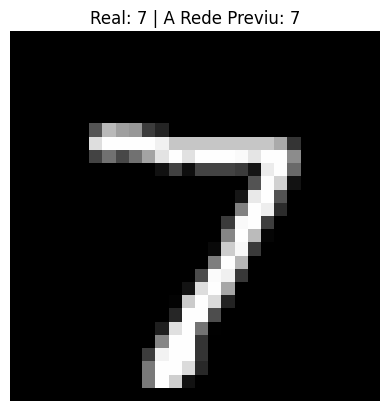

In [14]:
imagem_teste = X_test[0]
label_real = y_test[0]

previsao = cnn.predict(imagem_teste.reshape(1, 28, 28, 1))
numero_previsto = np.argmax(previsao)

plt.imshow(imagem_teste.reshape(28, 28), cmap='gray')
plt.title(f"Real: {label_real} | A Rede Previu: {numero_previsto}")
plt.axis('off')
plt.show()